# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [179]:
# Installing the required libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [180]:
# import required libraries for data manipulation using numpy and pandas
import numpy as np
import pandas as pd

# import required libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [181]:
# Connect to Google Drive to read and load the data
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [182]:
# read the foodhub_order.csv dataset from google drive using pandas.read_csv
data = pd.read_csv('/content/drive/MyDrive/notebooks_data/FoodHub_Project/foodhub_order.csv')

In [183]:
# code to view the first 5 rows
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [184]:
#code to see the last 5 rows
data.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [185]:
# Get the total no of rows and columns in the dataframe
print("The foodhub orders dataset has", data.shape[0], 'rows and', data.shape[1], "columns.")

The foodhub orders dataset has 1898 rows and 9 columns.


#### Observations:

*   The data set provided for the foodhub orders has 1898 rows and 9 columns by the name of order_id, customer_id, restaurant_name,cusine_type, cost_of_the_order, day_of_the_week, rating,food_preparation_time and delivery_time.
*   Rating column seems to have some values "Not Given" as a value which is being treated as string hence python identifies datatype as object for rating column.




### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [186]:
# Get datatypes for the different columns in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
There are 9 columns present in the dataset.

*   The columns order_id,customer_id, Cost_of_the_order, food_preparation_time and delivery_time are identified as numerical datatypes
*   restaurant_name, cuisine_type, day_of_the_week are identified as categorical datatypes
*   Rating column has datatype as object which may be due to some of the ratings stored as "Not Given".





### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [187]:
#checking for missing values on the current data
data.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


In [188]:
#checking for unique values for the columns with object datatypes
data['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

In [189]:
#replacing the 'Not given' (missing) values for rating column with NaN values for python interpretation.
data['rating'] = data['rating'].replace(['Not given'],np.nan)
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [190]:
#changing the datatype for 'rating' as float64 and view the columns datatypes
data['rating'] = data['rating'].astype('float64')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 133.6+ KB


In [191]:
#checking for missing values on the current data
data.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,736
food_preparation_time,0
delivery_time,0


In [192]:
#checking for any duplicate values in the data to be excluded
data.duplicated().sum()

np.int64(0)

#### Observations:

*   There are no columns with missing values.
*   However when checking the unique values in the rating column, it has some
values reported as "Not Given" which means some of the food orders have not been rated.There were 736 order where customers did not provide any rating.
*   There are no duplicate values




### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [193]:
#Update the float format to display upto 2 places after decimal
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [194]:
#statistical summary
data.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.00,1477495.50,548.05,1476547.00,1477021.25,1477495.50,1477969.75,1478444.00
customer_id,1898.00,171168.48,113698.14,1311.00,77787.75,128600.00,270525.00,405334.00
cost_of_the_order,1898.00,16.50,7.48,4.47,12.08,14.14,22.30,35.41
rating,1162.00,4.34,0.74,3.00,4.00,5.00,5.00,5.00
food_preparation_time,1898.00,27.37,4.63,20.00,23.00,27.00,31.00,35.00
delivery_time,1898.00,24.16,4.97,15.00,20.00,25.00,28.00,33.00


#### Observations:

*   Minimum time to prepare food once order is placed is 20 mins.
*   Average time to prepare food once order is placed is 27 mins.

*   Maximum time to prepare food once order is placed is 35 mins.
*   50% of orders for all restaurants was rated 5.0 but with consideration that there were multiple orders (736) which were not rated.

*   Mean rating for all rated orders was 4.34












### **Question 5:** How many orders are not rated? [1 mark]

In [195]:
# No of entries in the rating column which were replaced with NaN values.
data_rating_unrated = data['rating'].isnull().sum()
data_rating_unrated

np.int64(736)

#### Observations:
736 orders were not rated.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [196]:
# check unique order ID
print("There are", data['order_id'].nunique(), "unique food orders provided in the dataset")

There are 1898 unique food orders provided in the dataset


In [197]:
# check unique customer ID
print("Food is being ordered by", data['customer_id'].nunique(), "different customers")

Food is being ordered by 1200 different customers


In [198]:
# check unique Restaurant Name
print("Customers are ordering food from", data['restaurant_name'].nunique(), "different restaurants")

Customers are ordering food from 178 different restaurants


In [199]:
# Check unique cuisine type
print("There are", data['cuisine_type'].nunique(), "different cuisine type of food ordered by customers")

There are 14 different cuisine type of food ordered by customers


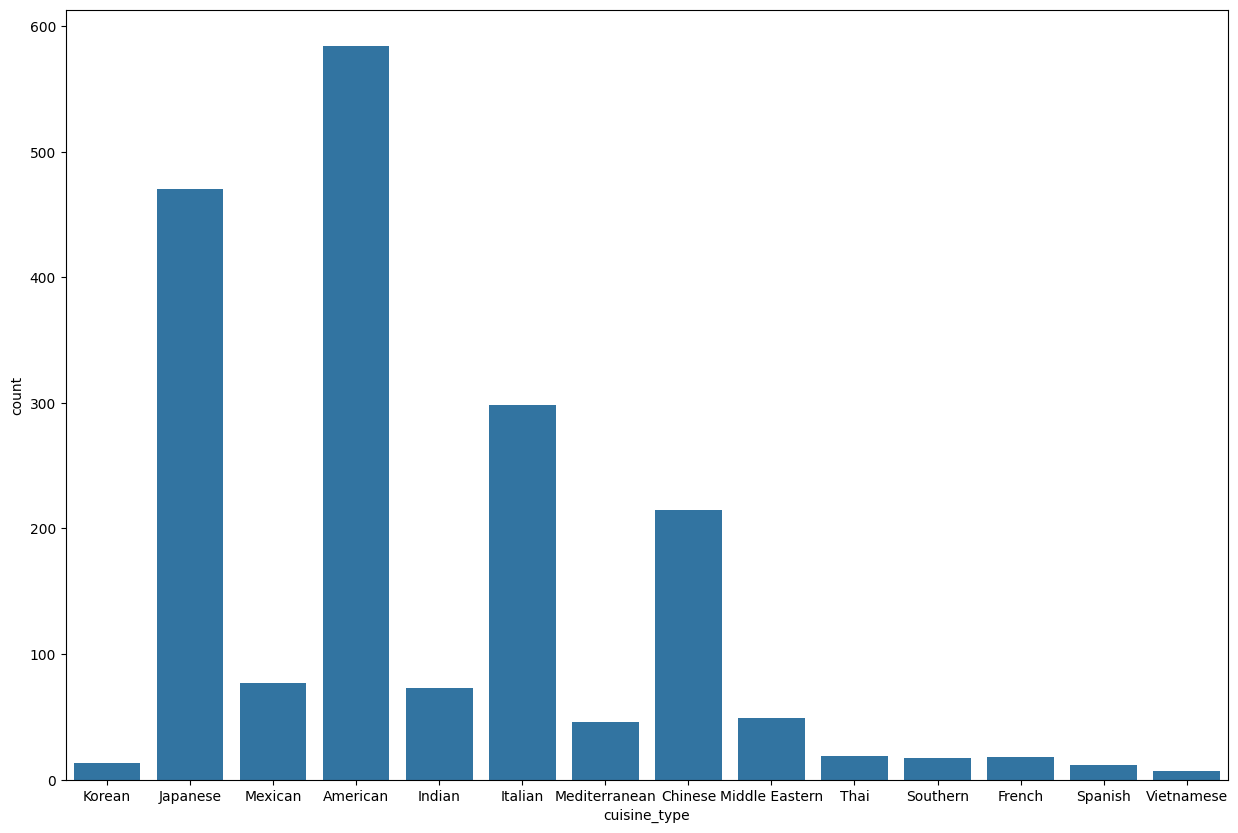

In [200]:
#Observations for countplot for cuisine type.
plt.figure(figsize = (15,10))
sns.countplot(data = data, x = 'cuisine_type');

Highest no of food orders are of cuisine_type american , followed by Japanese, Italian and Chinese cuisines.

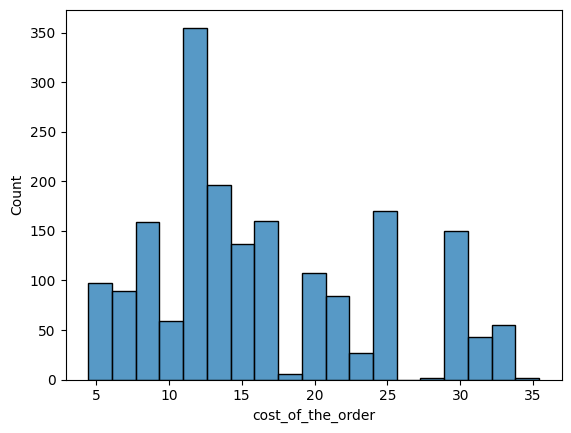

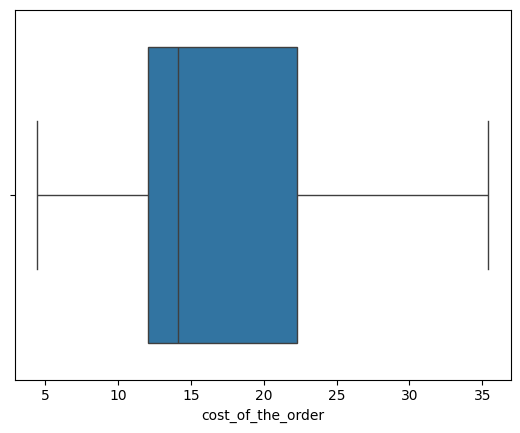

In [201]:
# Observations on hist plot for cost_of_the_order
sns.histplot(data=data,x='cost_of_the_order',stat='count')
plt.show()
sns.boxplot(data=data,x='cost_of_the_order')
plt.show()

In [202]:
print("Q1 is", np.percentile(data['cost_of_the_order'],25), "and Q3 is", np.percentile(data['cost_of_the_order'],75))

Q1 is 12.08 and Q3 is 22.2975


*   Q1 (25th percentile) is around 12
*   Q3 (75th percentile) is around 23
*   50% of the cost of orders are between 12 and 23 approximately
*   There are no outliers for cost of orders
*   Median cost is around 15, which indicates more than half of the items cost more than 15.

*   Distribution is slightly right skewed with some high cost orders contributing significantly to the revenue











In [203]:
#Observations for day_of_the_week
data['day_of_the_week'].unique()


array(['Weekend', 'Weekday'], dtype=object)

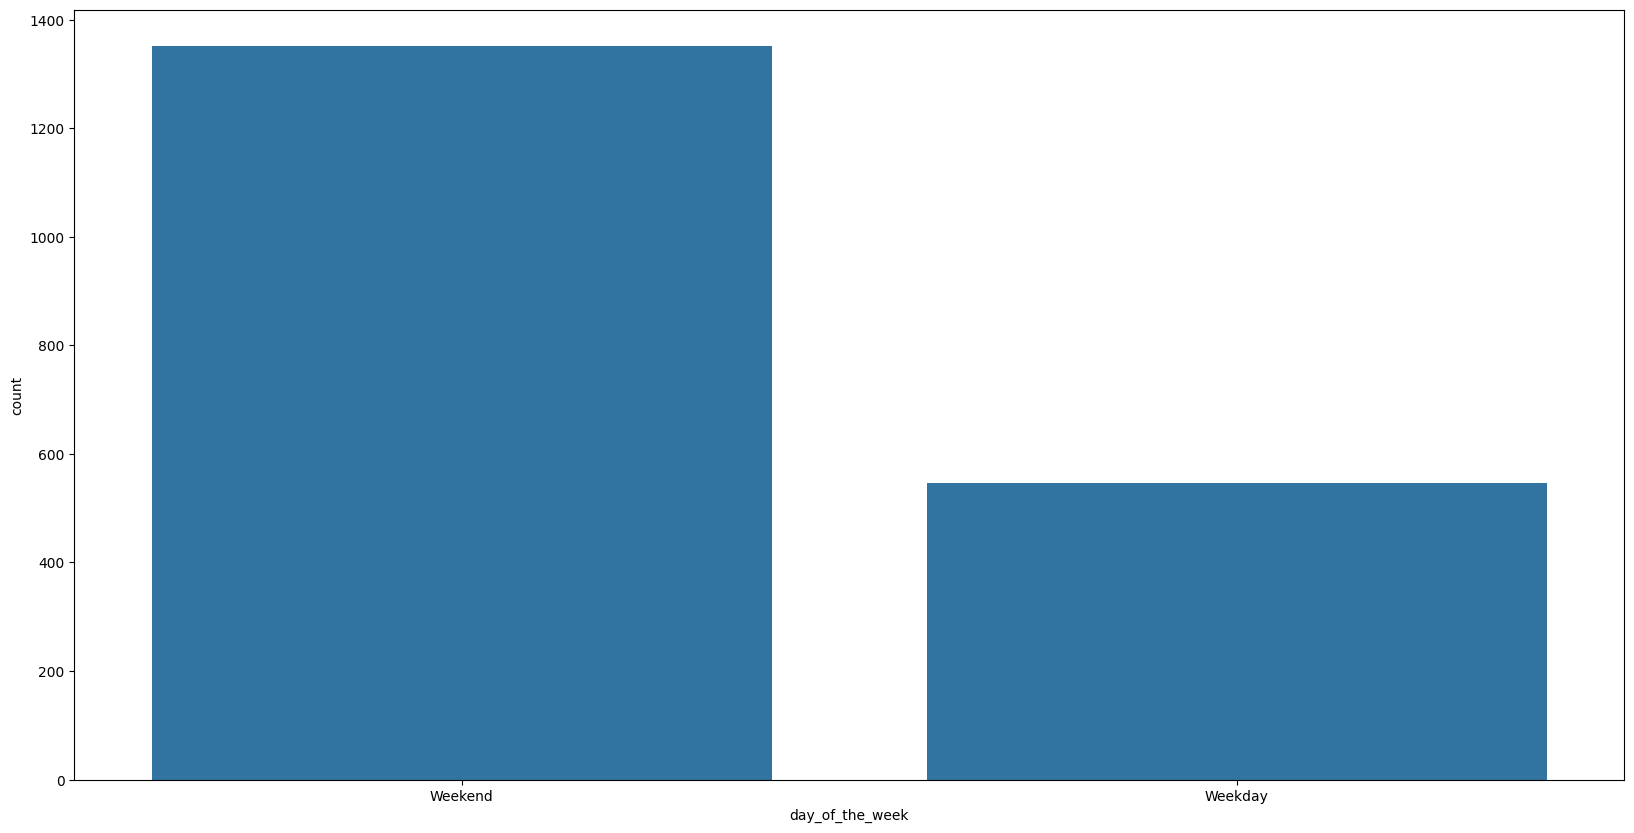

In [204]:
# Countplot for day_of_the_week
plt.figure(figsize = (20,10))
sns.countplot(data = data, x = 'day_of_the_week');



*  Food Orders on weekends are much higher than on weekdays signifying higher demand during weekends.
*  Weekends will be ideal for conducting food related promotions for scoring more orders



In [205]:
#Observations on rating
data['rating'].unique()

array([nan,  5.,  3.,  4.])

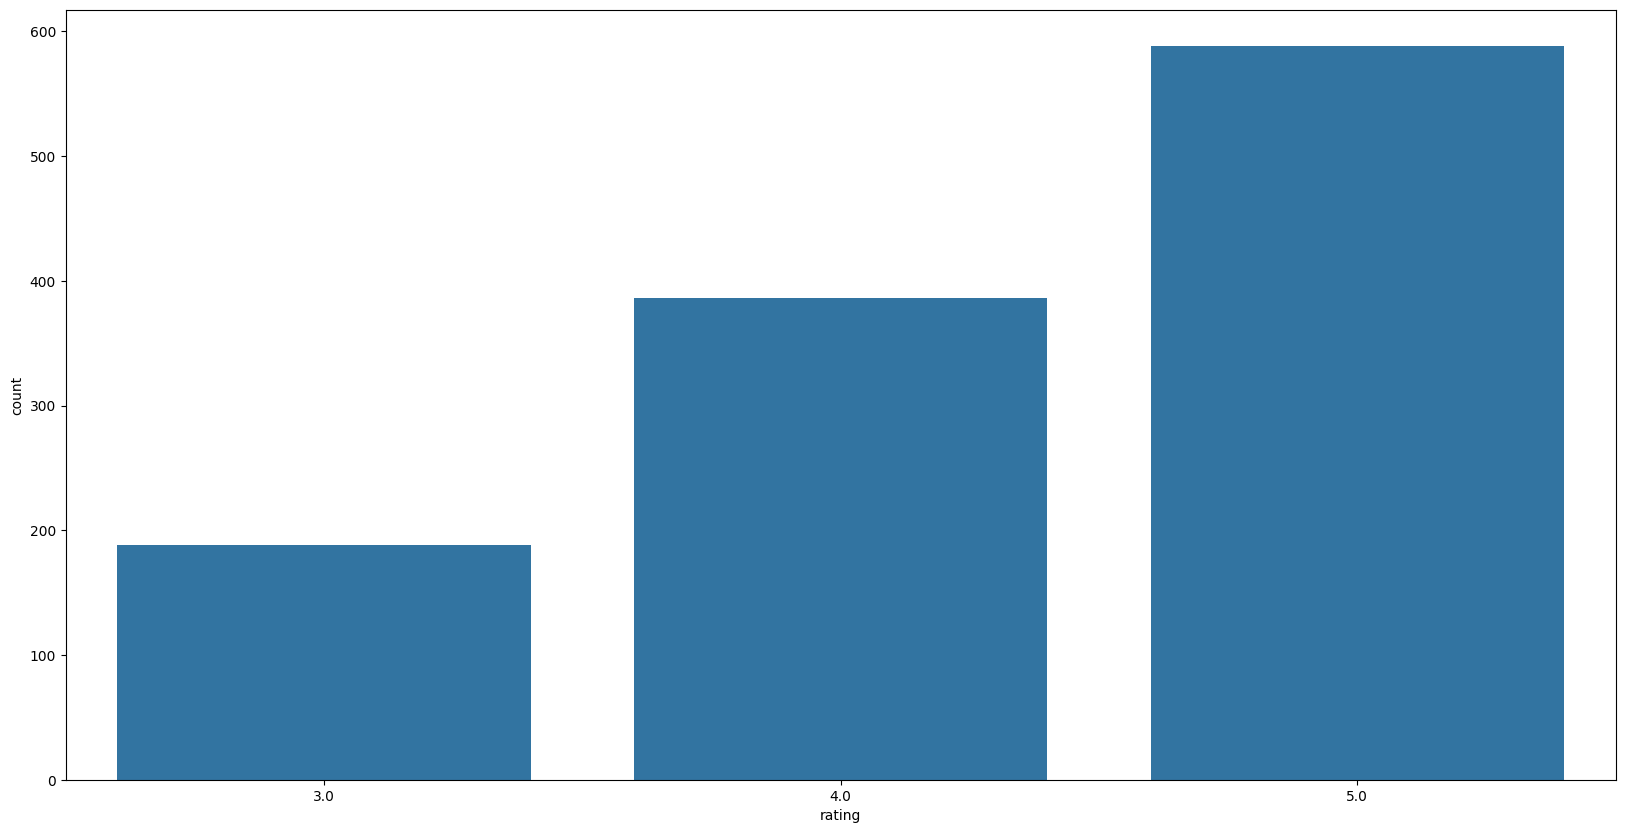

In [206]:
#countplot for ratings.
plt.figure(figsize = (20,10))
sns.countplot(data = data, x = 'rating');



*   Out of the 1898 orders, 736 orders were not rated.
*   Out of the remaining 1162 orders, nearly 580 orders were rated 5 stars, nearly 380 orders were rated 4 stars and remaining were 3 star ratings.

*   Most people who gave ratings have rated at 5 stars suggesting strong customer satisfaction.








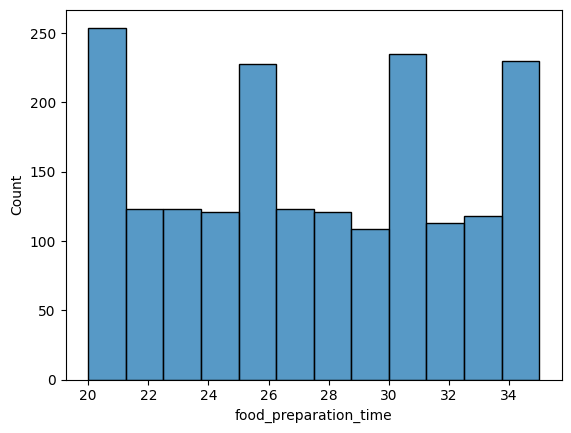

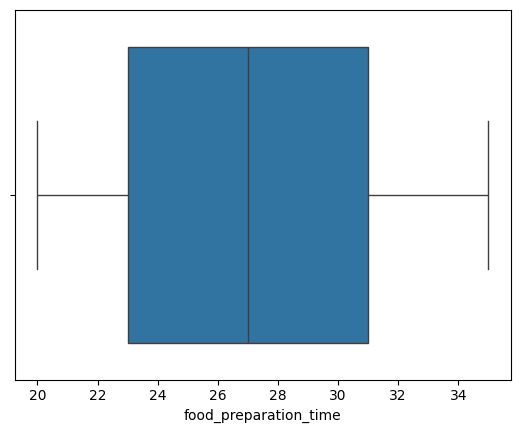

In [207]:
#Observations on food_preparation_time
sns.histplot(data=data,x='food_preparation_time',stat='count')
plt.show()
sns.boxplot(data=data,x='food_preparation_time')
plt.show()

In [208]:
print("Q1 is", np.percentile(data['food_preparation_time'],25), "and Q3 is", np.percentile(data['food_preparation_time'],75))

Q1 is 23.0 and Q3 is 31.0


*   Q1 (25th percentile) is around 23 mins
*   Q3 (75th percentile) is around 31 mins

*   50% of the orders have a food preparation time between 23 and 31 mins.
*   There are no outliers for food preparation times.


*   Overall customer satisfaction is high on the platform for food orders












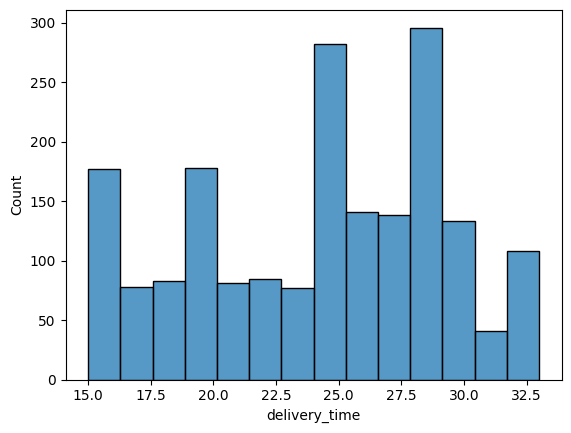

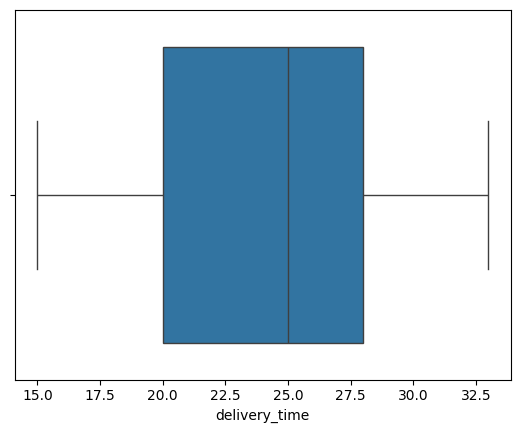

In [209]:
#Observations on food delivery time
sns.histplot(data=data,x='delivery_time',stat='count')
plt.show()
sns.boxplot(data=data,x='delivery_time')
plt.show()

In [210]:
print("Q1 is", np.percentile(data['delivery_time'],25), "and Q3 is", np.percentile(data['delivery_time'],75))

Q1 is 20.0 and Q3 is 28.0




*   Q1 (25th percentile) is around 20 mins
*   Q3 (75th percentile) is around 28 mins

*   50% of the orders have delivery time between 20 and 28 mins.
*   There are no outliers for delivery times.





### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [211]:
# Use value_counts and head for the top 5 restaurants
data['restaurant_name'].value_counts().head()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
Shake shack has 219 orders, followed by "The Meatball Shop" at 132, "Blue Ribbon Sushi" at 119, "Blue Ribbon Fried Chicken" at 96 and finally "Parm" at 68 orders

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [212]:
# Using day_of_the_week as Weekend, get the value_counts for cuisine_type
data[data['day_of_the_week']=='Weekend']['cuisine_type'].value_counts().head()

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53


#### Observations:


*   American food is the highest ordered food on weekends where no of orders are at 415 orders.
*   Japanese, Italian, Chinese and Mexican are the highest ordered behind American cuisine_type.
*   The company should prefer promoting american food and cuisine types during weekends





### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [213]:
# Get the percentage of orders more than 20
data_cost_more_than_20 = data[data['cost_of_the_order']>20].shape[0]
data_cost_more_than_20
print("The number of orders which cost more than 20 dollars is", data_cost_more_than_20)
print("The percentage of orders cost more than 20 dollars is", data[data['cost_of_the_order']>20].shape[0]/data.shape[0]*100)

The number of orders which cost more than 20 dollars is 555
The percentage of orders cost more than 20 dollars is 29.24130663856691


#### Observations:

*   555 orders cost more than 20 dollars
*   29 percentage of orders cost more than 20 dollars.




### **Question 10**: What is the mean order delivery time? [1 mark]

In [214]:
# Get the mean order delivery time
print("The mean order delivery time is", data['delivery_time'].mean())

The mean order delivery time is 24.161749209694417


#### Observations:
*   Mean order delivery time is approx 24 mins.



### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [215]:
# Getting the top 3 customers who places the most orders
print("Below are the top 3 customers who placed the most orders with their customer id and no of orders information", data['customer_id'].value_counts().head(5))

Below are the top 3 customers who placed the most orders with their customer id and no of orders information customer_id
52832     13
47440     10
83287      9
250494     8
259341     7
Name: count, dtype: int64


#### Observations:


*   Customer_ID 52832 had placed 13 orders
*   Customer_ID 47440 had placed 10 orders
*   Customer_ID 83287 had placed 9 orders

*   Above customers are eligible for the 20% discount vouchers.
*   Customers with higher orders placed should get the loyalty benefits for retention.







### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


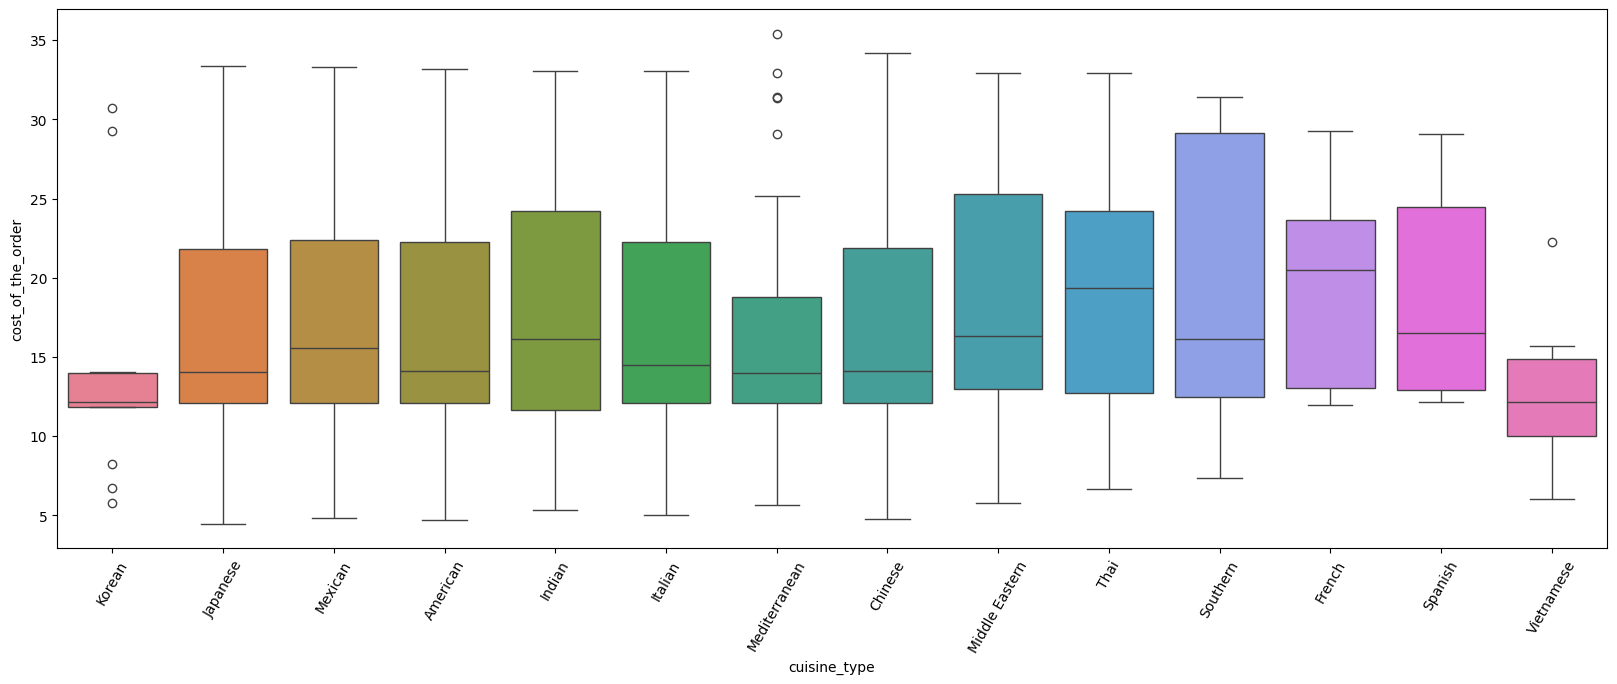

In [216]:
# Analysis for cost_of_the_order and cuisine type
plt.figure(figsize=(20,7))
sns.boxplot(x = "cuisine_type", y = "cost_of_the_order", data = data, hue = "cuisine_type")
plt.xticks(rotation = 60)
plt.show()



*   Southern Cuisine type has the highest cost for orders
*   There are some outliers for Korean, Mediterranean and Vietnamese cuisine types

*   The median cost_of_the_order price value across all cuisine types is between 11 dollars to 22 dollars
*   Highest median is for French cuisine while lowest median is for Korean and vietnamese cuisines.

*   Some cuisines have higher median/average order prices.

*   Higher value cuisines can be prioritized for promotions for more sales based on the patterns.









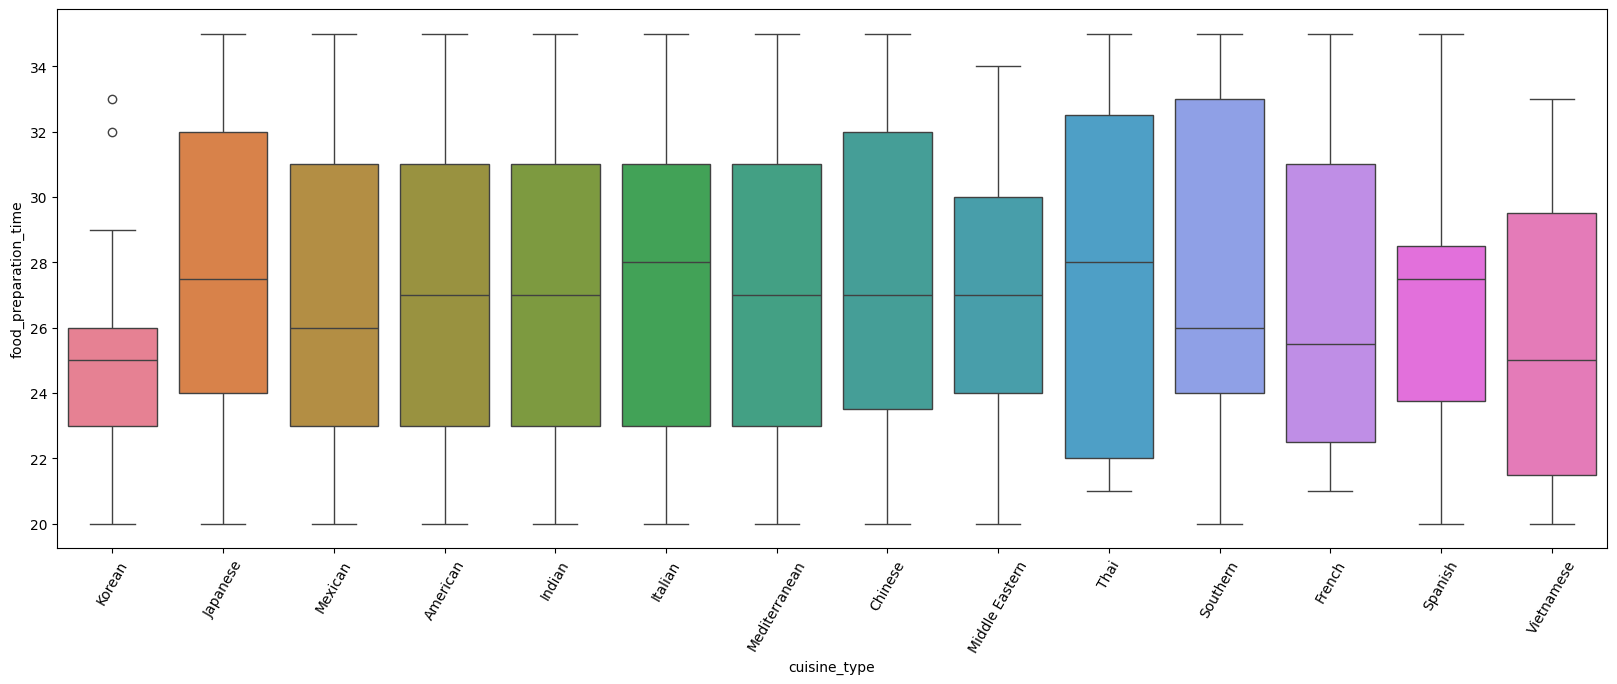

In [217]:
# Analysis for food_preparation_time and cuisine type
plt.figure(figsize=(20,7))
sns.boxplot(x = "cuisine_type", y = "food_preparation_time", data = data, hue = "cuisine_type")
plt.xticks(rotation = 60)
plt.show()

###Observations

*   Food Preparation times are relatively similar across all cuisine types.
*   Median/Average food preparation times is between 25 to 29 mins.
*   There are some outliers for Korean food preparation times which take longer times.
*   Operational cooking processes seems to take similar times across various cuisines.







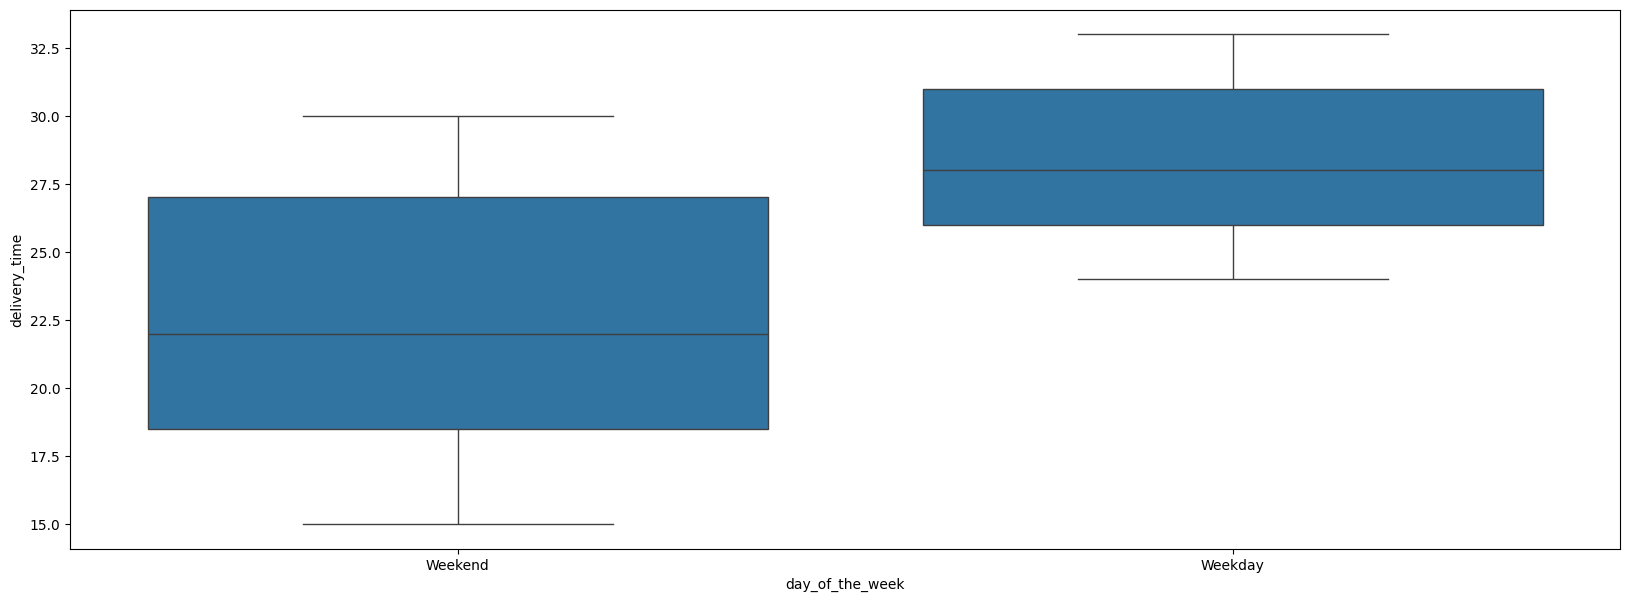

In [218]:
#Analysis between day_of_the_week and delivery_time
plt.figure(figsize=(20,7))
sns.boxplot(x = "day_of_the_week", y = "delivery_time", data = data)
plt.show()

##Observations
*   Mean delivery times are higher during the weekdays around 28 mins showing higher operational inefficiency or congestion.
*   Mean delivery times are lower during weekends around 22 mins.
*   Weekend demands are higher and staffing is able to manage them efficiently based on patterns.





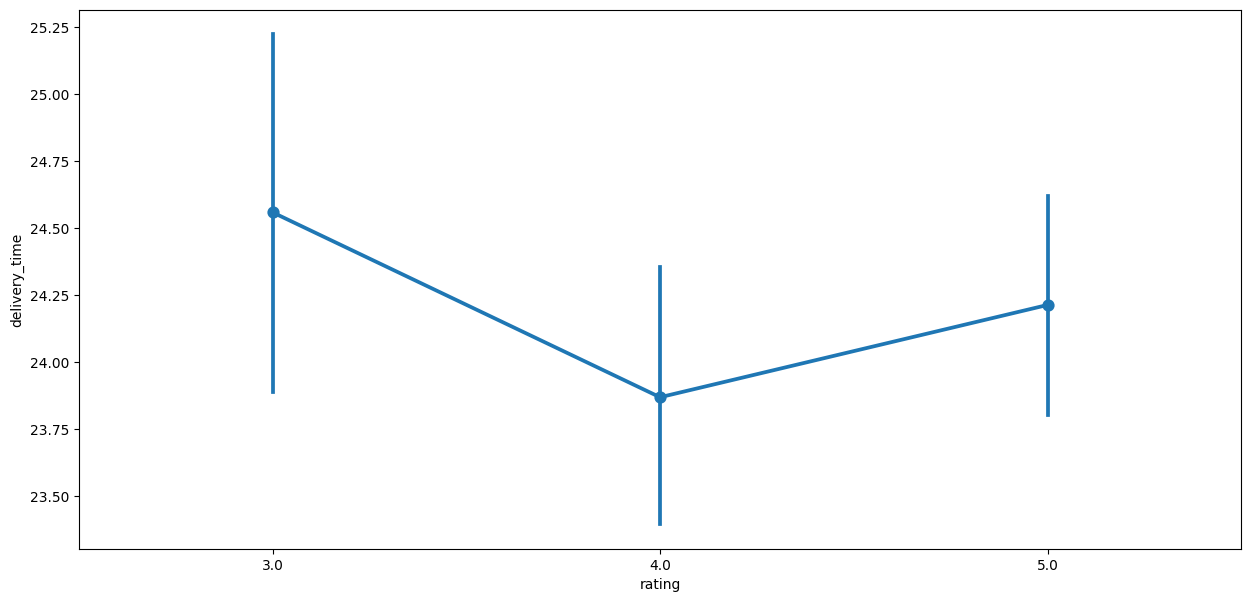

In [219]:
#Analysis for rating and delivery_time relationships
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'delivery_time', data = data)
plt.show()

###Observations

*   Delivery times remain consistent across customer ratings.
*   Ratings also reflect strong customer satisfaction.

*   Median/average delivery time across different rated customer orders is between 24-25 mins.





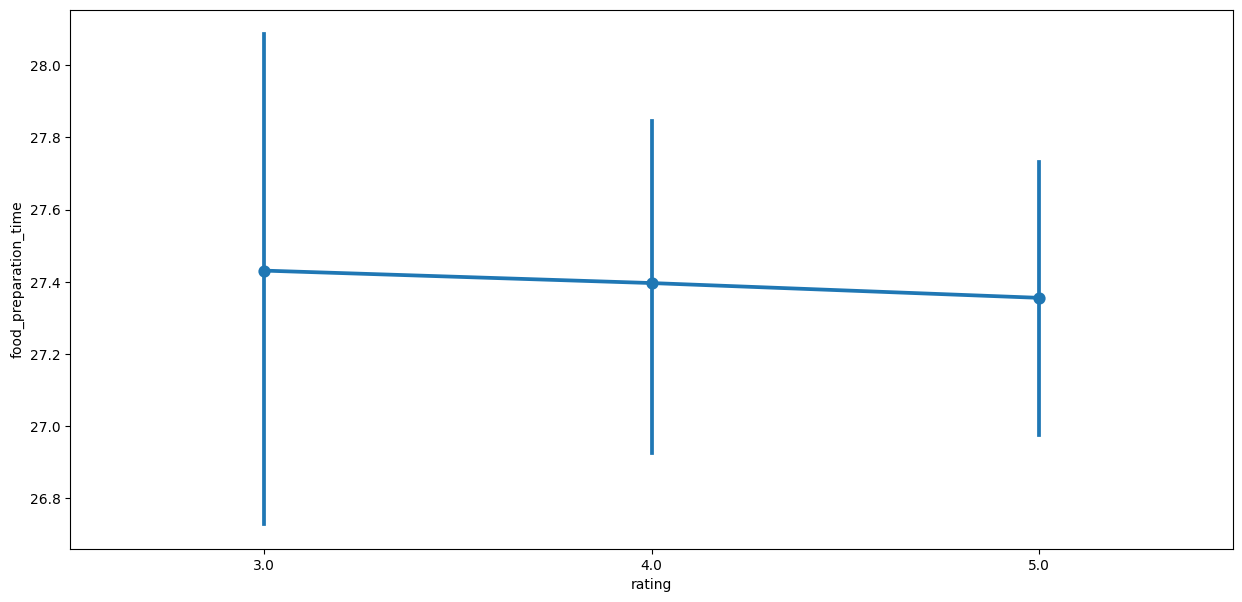

In [220]:
#Analysis between rating and food_preparation_time
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'food_preparation_time', data = data)
plt.show()

##Observations


*   Food preparation times are consistent across different customer ratings.
*   Customer ratings show limited correlation with food preparation times.



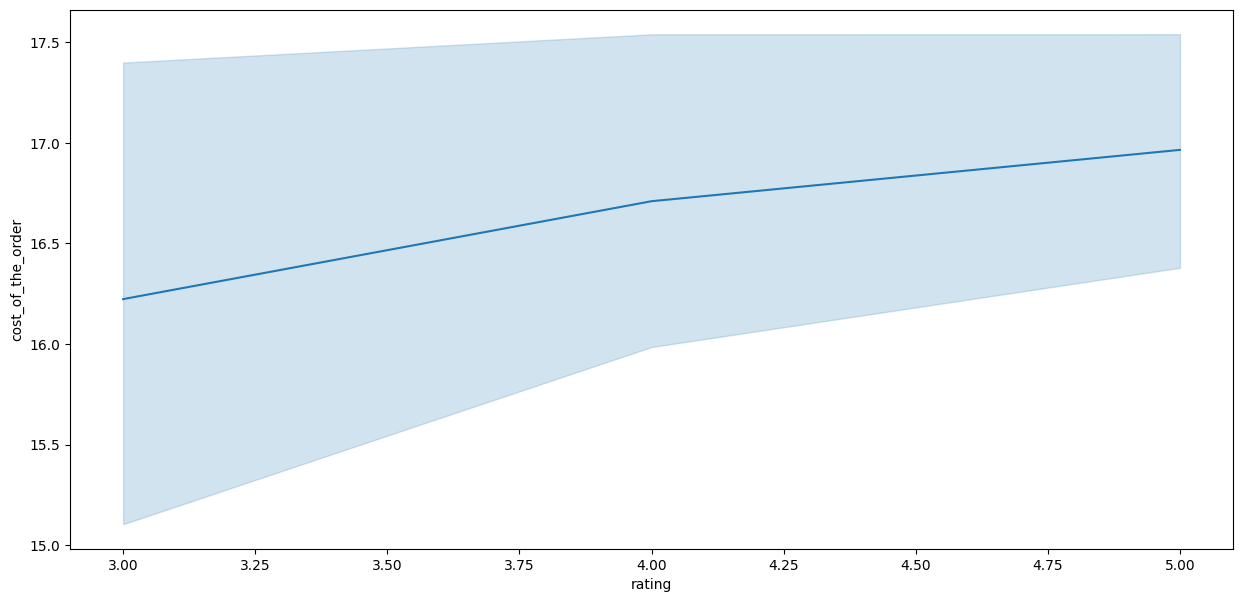

In [221]:
#Analysis between rating and cost_of_the_order
plt.figure(figsize=(15, 7))
sns.lineplot(x = 'rating', y = 'cost_of_the_order', data = data)
plt.show()

##Observations


*   Based on the patterns, spending more doesnt result in higher or lower ratings
*   Customers have good satisfaction with high priced food items in various cuisine types.



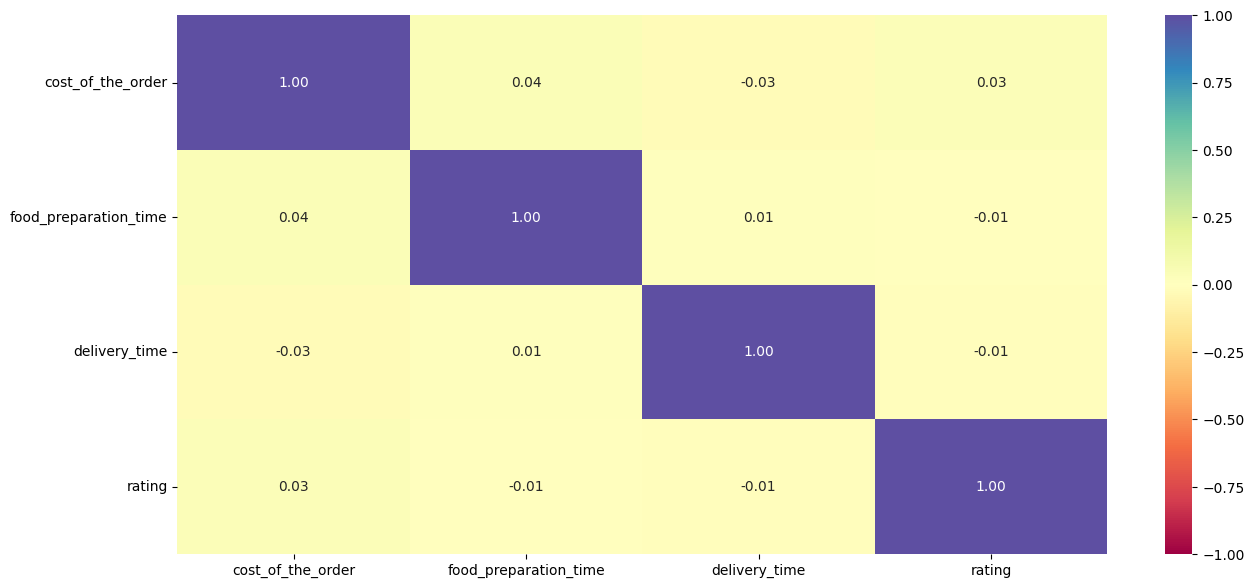

In [222]:
#Correlation among multiple variables
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']
plt.figure(figsize=(15, 7))
sns.heatmap(data[col_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

###Observations

*   The heatmap above doesnt show significant correlation between cost_of_the_order,food_preparation_time and delivery_time
*   No correlation between order cost and preparation time as they essentially independent.
*   Negligible negative correlation between cost_of_the_order and delivery_time i.e. costlier orders dont arrive meaningfully faster or slower.
*   No correlation between food_preparation_times and ratings noticeably longer preparation times doesnt hurt ratings.
*   Also negligible correlation between delivery_time and ratings, i.e. longer delivery times dont meaningfully lower customer ratings in the dataset.




In [223]:
#Revenue generated by each restaurant for various orders
data.groupby(['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending = False).head(5)

,cost_of_the_order
restaurant_name,
Shake Shack,3579.53
The Meatball Shop,2145.21
Blue Ribbon Sushi,1903.95
Blue Ribbon Fried Chicken,1662.29
Parm,1112.76


### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [224]:
# Exclude the unrated orders
data_rated = data[data['rating'].notnull()]
data_rated.head(5)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.00,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.00,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.00,25,24
5,1477224,147468,Tamarind TriBeCa,Indian,25.22,Weekday,3.00,20,24
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3.00,33,30


In [225]:
data_rated.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1162 entries, 2 to 1896
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1162 non-null   int64  
 1   customer_id            1162 non-null   int64  
 2   restaurant_name        1162 non-null   object 
 3   cuisine_type           1162 non-null   object 
 4   cost_of_the_order      1162 non-null   float64
 5   day_of_the_week        1162 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1162 non-null   int64  
 8   delivery_time          1162 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 90.8+ KB


In [226]:
#create the list of restaurants with the rating counts
rating_count = data_rated.groupby('restaurant_name')['rating'].count().sort_values(ascending = False).reset_index()
rating_count.head()

,restaurant_name,rating
0,Shake Shack,133
1,The Meatball Shop,84
2,Blue Ribbon Sushi,73
3,Blue Ribbon Fried Chicken,64
4,RedFarm Broadway,41


In [227]:
#find the list of restaurants and the ratings with more than 50 ratings
data_rest_name = rating_count[rating_count['rating']>50]
data_rest_name.head()

,restaurant_name,rating
0,Shake Shack,133
1,The Meatball Shop,84
2,Blue Ribbon Sushi,73
3,Blue Ribbon Fried Chicken,64


In [228]:
#filter to get the data for each restaurant with more than 50 ratings
data_mean_rating = data_rated[data_rated['restaurant_name'].isin(data_rest_name['restaurant_name'])]
data_mean_rating

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.00,25,15
12,1476966,129969,Blue Ribbon Fried Chicken,American,24.30,Weekend,5.00,23,17
15,1477414,66222,Shake Shack,American,16.20,Weekend,5.00,33,25
19,1477354,67487,Blue Ribbon Sushi,Japanese,16.20,Weekend,4.00,35,26
22,1478287,150599,Shake Shack,American,29.10,Weekday,5.00,21,30
...,...,...,...,...,...,...,...,...,...
1880,1477466,222734,Shake Shack,American,13.97,Weekend,5.00,35,27
1884,1477437,304993,Shake Shack,American,31.43,Weekend,3.00,31,24
1885,1477550,97324,Shake Shack,American,29.05,Weekday,4.00,27,29
1886,1478277,48282,The Meatball Shop,American,14.50,Weekend,5.00,34,25


In [229]:
#group the restaurant name with their ratings and find the mean rating
data_mean_rest_rating = data_mean_rating.groupby('restaurant_name')['rating'].mean().sort_values(ascending = False).reset_index().query("rating>4")
data_mean_rest_rating

,restaurant_name,rating
0,The Meatball Shop,4.51
1,Blue Ribbon Fried Chicken,4.33
2,Shake Shack,4.28
3,Blue Ribbon Sushi,4.22


In [230]:
#print the restaurants who qualify for the offer
print("The restaurants who qualify for the promotional offer are ", data_mean_rest_rating['restaurant_name']);

The restaurants who qualify for the promotional offer are  0            The Meatball Shop
1    Blue Ribbon Fried Chicken
2                  Shake Shack
3            Blue Ribbon Sushi
Name: restaurant_name, dtype: object


#### Observations:
Only 4 restaurants qualify for the promotional offer The Meatball Shop,Blue Ribbon Fried Chicken,Shake Shack,Blue Ribbon Sushi.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [231]:
print("Total cost of orders for all restaurants is", data['cost_of_the_order'].sum())
#restaurants where cost of orders > 20
data[data['cost_of_the_order']>20]

#total sum of orders where cost of order >20
data[data['cost_of_the_order']>20].sum()['cost_of_the_order']

#revenue from restaurant where total cost of order > 20 =.25 of total cost
revenue1 =data[data['cost_of_the_order']>20].sum()['cost_of_the_order']*.25


#restaurants where cost of orders > 5
data[(data['cost_of_the_order']>5) & (data['cost_of_the_order']<=20)]

#total sum of orders where cost of order >5
data[(data['cost_of_the_order']>5) & (data['cost_of_the_order']<=20)].sum()['cost_of_the_order']

#revenue from restaurant where total cost of order > 5 =.15 of total cost
revenue2 =data[(data['cost_of_the_order']>5) & (data['cost_of_the_order']<=20)].sum()['cost_of_the_order']*.15

totalRevenue = revenue1+revenue2
print("Total revenue of company from all restaurants is", totalRevenue)
print("Revenue was",totalRevenue/data['cost_of_the_order'].sum()*100,"% of the total cost of orders")



Total cost of orders for all restaurants is 31314.82
Total revenue of company from all restaurants is 6166.303
Revenue was 19.691325065895317 % of the total cost of orders


#### Observations:
The total revenue was generated by calculating 25% of total cost of orders where cost of order was greater than 20 and adding that to revenue that was generated by calculating 15% of total cost of orders where cost of order was
greater than 5 and less than 20.
*   The total revenue generated was around $6166.
*   Revenue was around 19% of the total cost





### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [232]:
# Create new column in dataframe called total_time which is a sum of preparation Time + delivery time
data['total_time']=data['food_preparation_time']+data['delivery_time']
data.head()

#Now find the number of rows where total_time >60
data[data['total_time']>60].shape[0]

#Find the percentage of orders where total_time >60
data[data['total_time']>60].shape[0]/data.shape[0]*100

10.537407797681771

#### Observations:
A little more than 10% of the orders took more than 60 minutes from start of order to being delivered.



### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [233]:
print("The Mean DeliveryTime during Weekend is", data[data['day_of_the_week']=='Weekend']['delivery_time'].mean())

print("The Mean DeliveryTime during Weekdays is", data[data['day_of_the_week']=='Weekday']['delivery_time'].mean())

The Mean DeliveryTime during Weekend is 22.4700222057735
The Mean DeliveryTime during Weekdays is 28.340036563071298


#### Observations:
The mean delivery time on Weekdays was higher than on weekends.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
The food hub business continues to demonstrate strong performance across customer experience, operational execution, and revenue generation. Customer satisfaction remains high, supported by consistent service quality from top‑performing restaurants and minimal impact from delivery delays. Operational metrics show stability in preparation and delivery times, with weekend performance outperforming weekdays and most delay incidents isolated to specific restaurant partners rather than systemic issues. Revenue trends highlight the importance of average order value, with a small group of high‑performing restaurants driving a significant share of earnings. Promotional targeting and basket‑building strategies present clear opportunities to enhance profitability, while the current pricing and commission structure remains effective in sustaining growth.

### Customer Experience Performance
*   Satisfaction levels remain strong, indicating sustained customer trust and a healthy platform experience.
*   Delivery delays have limited influence on overall sentiment, suggesting resilience in customer expectations.
*   High‑volume restaurants consistently deliver reliable service quality, reinforcing platform credibility.

### Operational Performance
*   Preparation and delivery times remain stable, reflecting operational consistency.
*   Weekend logistics outperform weekday operations, highlighting opportunities to rebalance resources.
*   Delay incidents are concentrated within specific restaurants, indicating targeted intervention rather than broad operational redesign.

### Revenue Performance
*   Revenue is highly sensitive to average order value, underscoring the importance of upsell and cross‑sell strategies.
*   A small group of top restaurants contributes disproportionately to total earnings, reinforcing the value of strategic partner management.
*   Targeted promotions can further improve profitability, supported by an effective pricing and commission model.







### Recommendations:
The conclusion items outlined point to three clear opportunity areas: strengthening customer loyalty, tightening operational performance, and accelerating revenue growth. The recommendations below translate those signals into actionable, business‑ready priorities.

## Customer Experience Recommendations
*  **Reduce the remaining friction points in delivery** by focusing on the small subset of restaurants driving delay incidents. A targeted coaching and SLA‑reinforcement program can lift platform‑wide satisfaction without broad operational changes.
*   **Strengthen loyalty mechanisms** (e.g., rewards for consistent ordering, personalized offers) to capitalize on already strong satisfaction levels and deepen repeat behavior.
*   **Leverage high‑performing restaurants as benchmarks**, using their operational patterns and service models to guide improvement plans for mid‑tier partners.

## Operational Efficiency Recommendations
*   **Rebalance staffing and logistics resources** to align with weekend outperformance. Weekday bottlenecks may be mitigated through dynamic driver allocation, staggered prep windows, or micro‑fulfillment adjustments.
*   **Deploy restaurant‑specific operational diagnostics** for partners with recurring delays. This avoids unnecessary system‑wide interventions and ensures effort is directed where it will have the highest impact.
*   **Invest in scalable process automation**, such as predictive prep-time adjustments or automated dispatching, to maintain stability as order volumes grow.

## Revenue Growth Recommendations
*   **Prioritize basket‑building strategies** (e.g., smart add‑ons, combo suggestions, minimum‑order incentives) to capitalize on revenue sensitivity to order value.
*   **Develop tailored growth plans for top‑performing restaurants**, including exclusive promotions, premium placement, or co‑marketing, given their outsized contribution to earnings.
*   **Refine promotional targeting** using customer behavior data to drive higher ROI, focusing on segments most responsive to incentives.
*   **Maintain the current pricing and commission structure**, while exploring selective adjustments for high‑elasticity categories to unlock incremental margin.

## Strategic Synthesis
The platform is performing well, but the next wave of growth will come from **precision**, not broad changes. Focusing on the specific restaurants, customer segments, and operational windows that drive disproportionate impact will yield the highest return. The combination of targeted operational fixes, smarter revenue levers, and loyalty‑driven customer engagement positions the business for sustainable, scalable expansion.












---

In [235]:
!jupyter nbconvert /content/drive/MyDrive/notebooks_data/FoodHub_Project/PYF_Project_Foodhub_Jan26_DebasishNanda.ipynb --to html

[NbConvertApp] Converting notebook /content/drive/MyDrive/notebooks_data/FoodHub_Project/PYF_Project_Foodhub_Jan26_DebasishNanda.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 16 image(s).
[NbConvertApp] Writing 939968 bytes to /content/drive/MyDrive/notebooks_data/FoodHub_Project/PYF_Project_Foodhub_Jan26_DebasishNanda.html
